# Systematic Factor Strategy Backtest

This project builds a systematic equity strategy using momentum and volatility factors, then evaluates long-only and long/short implementations versus the S&P 500.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

%matplotlib inline

## Data Collection & Preparation

In [29]:
tickers = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META",
    "GOOGL", "JPM", "XOM", "UNH", "COST",
    "LLY", "AVGO", "V", "MA", "HD"
]

benchmark = "SPY"

In [30]:
start_date = "2018-01-01"
end_date = "2026-01-01"

prices = yf.download(
    tickers + [benchmark],
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  16 of 16 completed


Ticker,AAPL,AMZN,AVGO,COST,GOOGL,HD,JPM,LLY,MA,META,MSFT,NVDA,SPY,UNH,V,XOM
Date,,,,,,,,,,,,,,,,
2018-01-02,40.304169,59.450500,21.086660,168.253998,53.220634,153.792923,85.901260,75.026711,144.809280,180.007385,78.870354,4.928267,236.562119,193.090469,108.111916,58.580441
2018-01-03,40.297157,60.209999,21.317265,170.273163,54.128624,154.594452,85.988800,75.434242,146.630035,183.232086,79.237434,5.252614,238.058456,195.116028,109.188210,59.730930
2018-01-04,40.484337,60.479500,21.324377,168.950943,54.338890,155.821320,87.220634,75.770950,148.526993,182.894745,79.934814,5.280302,239.061829,195.962906,109.594177,59.813625
2018-01-05,40.945267,61.457001,21.450729,167.744751,55.059433,157.448975,86.660698,76.701256,151.606003,185.395142,80.925842,5.325050,240.654968,199.699615,112.218880,59.765400
2018-01-08,40.793179,62.343498,21.502058,168.396942,55.253830,157.072693,86.788712,76.311401,152.064331,186.813965,81.008430,5.488212,241.095032,196.233536,112.672020,60.034100


In [31]:
prices.isna().sum()

Ticker
AAPL     0
AMZN     0
AVGO     0
COST     0
GOOGL    0
HD       0
JPM      0
LLY      0
MA       0
META     0
MSFT     0
NVDA     0
SPY      0
UNH      0
V        0
XOM      0
dtype: int64

In [32]:
monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna()

monthly_prices.head()

Ticker,AAPL,AMZN,AVGO,COST,GOOGL,HD,JPM,LLY,MA,META,MSFT,NVDA,SPY,UNH,V,XOM
Date,,,,,,,,,,,,,,,,
2018-01-31,39.174076,72.544502,19.587748,174.106140,58.626450,164.319519,92.523956,72.164925,161.354111,185.434799,87.184090,6.076589,248.118729,206.727951,117.288818,60.144302
2018-02-28,41.845181,75.622498,19.463762,171.015533,54.743546,149.081711,92.387978,68.747803,167.808258,176.931534,86.450424,5.986364,239.097031,197.455917,116.272987,52.713768
2018-03-31,39.416035,72.366997,18.882750,168.802780,51.431915,146.616882,87.964561,69.060211,167.235413,158.545807,84.145576,5.728851,232.543289,187.457794,113.133018,51.927311
2018-04-30,38.824013,78.306503,18.383537,176.623474,50.511528,152.013031,87.453918,72.362831,170.447098,170.660706,86.219925,5.563361,233.745071,207.079575,119.999329,54.112690
2018-05-31,44.070061,81.481003,20.198494,178.108856,54.549156,154.311661,86.030914,76.429855,181.777069,190.286713,91.519623,6.242292,239.427292,211.555786,123.829712,57.114784


## Momentum Strategy (Long Only)

In [33]:
momentum = monthly_prices.pct_change(12)
momentum = momentum.dropna()

momentum.head()

Ticker,AAPL,AMZN,AVGO,COST,GOOGL,HD,JPM,LLY,MA,META,MSFT,NVDA,SPY,UNH,V,XOM
Date,,,,,,,,,,,,,,,,
2019-01-31,0.009012,0.184604,0.132242,0.112957,-0.047648,-0.065817,-0.082062,0.508559,0.256262,-0.108085,0.118175,-0.413543,-0.024274,0.156532,0.094016,-0.125808
2019-02-28,-0.013101,0.084221,0.169656,0.157887,0.020499,0.038700,-0.073072,0.677536,0.285984,-0.094605,0.214898,-0.360522,0.045365,0.085455,0.212849,0.087623
2019-03-31,0.149376,0.230361,0.328400,0.298555,0.134745,0.102819,-0.055659,0.715831,0.351702,0.043182,0.314021,-0.222183,0.094281,0.171592,0.314424,0.128824
2019-04-30,0.232758,0.230115,0.444742,0.258431,0.177090,0.129136,0.097245,0.477000,0.434071,0.124419,0.420065,-0.192622,0.133130,-0.000287,0.304589,0.076264
2019-05-31,-0.048884,0.089254,0.039218,0.220984,0.005909,0.036688,0.018416,0.393033,0.330142,-0.074617,0.271635,-0.460865,0.035692,0.015214,0.242308,-0.090797


In [34]:
monthly_returns = monthly_returns.loc[momentum.index]

In [54]:
stock_momentum = momentum[tickers]

# Rank stocks each month (higher momentum = better)

ranks = stock_momentum.rank(axis=1, ascending=False)

ranks.head()

Ticker,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,XOM,UNH,COST,LLY,AVGO,V,MA,HD
Date,,,,,,,,,,,,,,,
2019-01-31,9.0,6.0,15.0,3.0,13.0,10.0,12.0,14.0,4.0,7.0,1.0,5.0,8.0,2.0,11.0
2019-02-28,12.0,3.0,15.0,9.0,14.0,11.0,13.0,7.0,8.0,6.0,1.0,5.0,4.0,2.0,10.0
2019-03-31,9.0,5.0,15.0,7.0,13.0,10.0,14.0,11.0,8.0,6.0,1.0,3.0,4.0,2.0,12.0
2019-04-30,7.0,4.0,15.0,8.0,11.0,9.0,12.0,13.0,14.0,6.0,1.0,2.0,5.0,3.0,10.0
2019-05-31,12.0,3.0,15.0,6.0,13.0,11.0,9.0,14.0,10.0,5.0,1.0,7.0,4.0,2.0,8.0


In [36]:
top_n = 5

signals = ranks <= top_n

signals.head()

Ticker,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,XOM,UNH,COST,LLY,AVGO,V,MA,HD
Date,,,,,,,,,,,,,,,
2019-01-31,False,False,False,True,False,False,False,False,True,False,True,True,False,True,False
2019-02-28,False,True,False,False,False,False,False,False,False,False,True,True,True,True,False
2019-03-31,False,True,False,False,False,False,False,False,False,False,True,True,True,True,False
2019-04-30,False,True,False,False,False,False,False,False,False,False,True,True,True,True,False
2019-05-31,False,True,False,False,False,False,False,False,False,True,True,False,True,True,False


In [37]:
stock_returns = monthly_returns[tickers]

strategy_returns = (stock_returns * signals).sum(axis=1) / top_n

strategy_returns.head()

Date
2019-01-31    0.088150
2019-02-28    0.065369
2019-03-31    0.056809
2019-04-30    0.040442
2019-05-31   -0.020616
Freq: ME, dtype: float64

In [38]:
spy_returns = monthly_returns[benchmark]

strategy_cum = (1 + strategy_returns).cumprod()
spy_cum = (1 + spy_returns).cumprod()

strategy_cum.tail(), spy_cum.tail()

(Date
 2025-08-31    21.579086
 2025-09-30    23.161369
 2025-10-31    25.318847
 2025-11-30    27.129046
 2025-12-31    26.700096
 Freq: ME, dtype: float64,
 Date
 2025-08-31    2.853564
 2025-09-30    2.955209
 2025-10-31    3.025654
 2025-11-30    3.031554
 2025-12-31    3.033971
 Freq: ME, Name: SPY, dtype: float64)

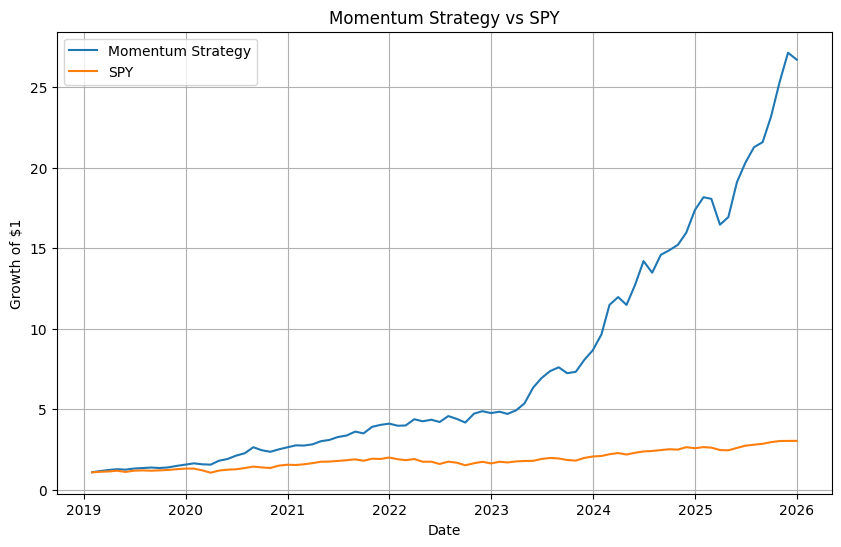

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(strategy_cum, label="Momentum Strategy")
plt.plot(spy_cum, label="SPY")

plt.title("Momentum Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
def annualized_return(returns):
    return (1 + returns).prod() ** (12 / len(returns)) - 1

def annualized_volatility(returns):
    return returns.std() * np.sqrt(12)

def sharpe_ratio(returns):
    return annualized_return(returns) / annualized_volatility(returns)

def max_drawdown(cumulative_returns):
    drawdown = cumulative_returns / cumulative_returns.cummax() - 1
    return drawdown.min()

performance = pd.DataFrame({
    "Momentum Strategy": [
        annualized_return(strategy_returns),
        annualized_volatility(strategy_returns),
        sharpe_ratio(strategy_returns),
        max_drawdown(strategy_cum)
    ],
    "SPY": [
        annualized_return(spy_returns),
        annualized_volatility(spy_returns),
        sharpe_ratio(spy_returns),
        max_drawdown(spy_cum)
    ]
}, index=[
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
])

performance

,Momentum Strategy,SPY
Annualized Return,0.598776,0.171814
Annualized Volatility,0.201177,0.165770
Sharpe Ratio,2.976357,1.036460
Max Drawdown,-0.108042,-0.239272


## Multi-Factor Strategy

In [41]:
volatility = monthly_returns[tickers].rolling(12).std()
volatility = volatility.loc[momentum.index]

volatility.head()

Ticker,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,XOM,UNH,COST,LLY,AVGO,V,MA,HD
Date,,,,,,,,,,,,,,,
2019-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
vol_ranks = volatility.rank(axis=1, ascending=True)

vol_ranks.head()

Ticker,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,XOM,UNH,COST,LLY,AVGO,V,MA,HD
Date,,,,,,,,,,,,,,,
2019-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
combined_score = ranks + vol_ranks

combined_score.head()

Ticker,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,XOM,UNH,COST,LLY,AVGO,V,MA,HD
Date,,,,,,,,,,,,,,,
2019-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
combined_ranks = combined_score.rank(axis=1, ascending=True)

combined_ranks.head()

Ticker,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,XOM,UNH,COST,LLY,AVGO,V,MA,HD
Date,,,,,,,,,,,,,,,
2019-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
multi_signals = combined_ranks <= top_n

multi_signals.head()

Ticker,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,XOM,UNH,COST,LLY,AVGO,V,MA,HD
Date,,,,,,,,,,,,,,,
2019-01-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2019-02-28,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2019-03-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2019-04-30,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2019-05-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [46]:
multi_strategy_returns = (stock_returns * multi_signals).sum(axis=1) / top_n

multi_strategy_returns.head()

Date
2019-01-31    0.0
2019-02-28    0.0
2019-03-31    0.0
2019-04-30    0.0
2019-05-31    0.0
Freq: ME, dtype: float64

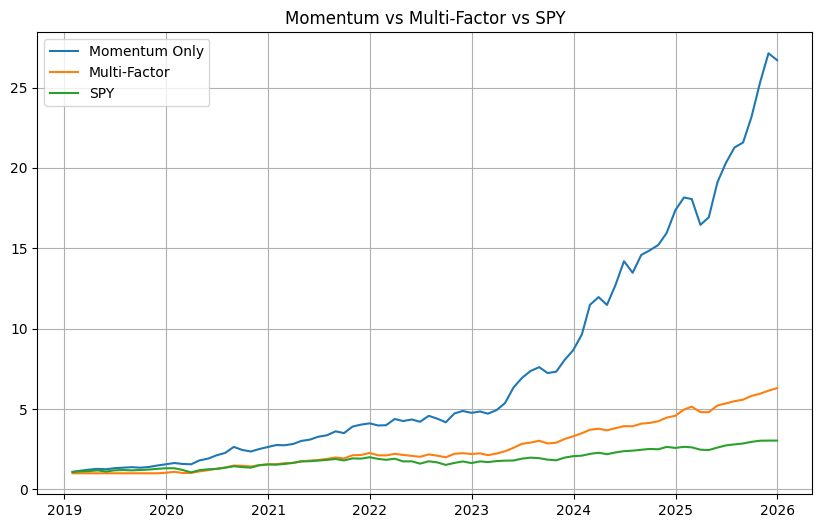

In [47]:
multi_cum = (1 + multi_strategy_returns).cumprod()

plt.figure(figsize=(10,6))

plt.plot(strategy_cum, label="Momentum Only")
plt.plot(multi_cum, label="Multi-Factor")
plt.plot(spy_cum, label="SPY")

plt.legend()
plt.title("Momentum vs Multi-Factor vs SPY")
plt.grid(True)
plt.show()

In [48]:
multi_performance = pd.DataFrame({
    "Multi-Factor": [
        annualized_return(multi_strategy_returns),
        annualized_volatility(multi_strategy_returns),
        sharpe_ratio(multi_strategy_returns),
        max_drawdown(multi_cum)
    ]
}, index=[
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
])

multi_performance

,Multi-Factor
Annualized Return,0.300726
Annualized Volatility,0.143373
Sharpe Ratio,2.097509
Max Drawdown,-0.119387


## Long/Short Strategy

In [49]:
long_n = 5
short_n = 5

long_signals = combined_ranks <= long_n
short_signals = combined_ranks > (len(tickers) - short_n)

long_signals.head(), short_signals.head()

(Ticker       AAPL   MSFT   NVDA   AMZN   META  GOOGL    JPM    XOM    UNH  \
 Date                                                                        
 2019-01-31  False  False  False  False  False  False  False  False  False   
 2019-02-28  False  False  False  False  False  False  False  False  False   
 2019-03-31  False  False  False  False  False  False  False  False  False   
 2019-04-30  False  False  False  False  False  False  False  False  False   
 2019-05-31  False  False  False  False  False  False  False  False  False   
 
 Ticker       COST    LLY   AVGO      V     MA     HD  
 Date                                                  
 2019-01-31  False  False  False  False  False  False  
 2019-02-28  False  False  False  False  False  False  
 2019-03-31  False  False  False  False  False  False  
 2019-04-30  False  False  False  False  False  False  
 2019-05-31  False  False  False  False  False  False  ,
 Ticker       AAPL   MSFT   NVDA   AMZN   META  GOOGL    JP

In [55]:
# Construct long/short portfolio (long top, short bottom)

long_returns = (stock_returns * long_signals).sum(axis=1) / long_n
short_returns = (stock_returns * short_signals).sum(axis=1) / short_n

long_short_returns = long_returns - short_returns

long_short_returns.head()

Date
2019-01-31    0.0
2019-02-28    0.0
2019-03-31    0.0
2019-04-30    0.0
2019-05-31    0.0
Freq: ME, dtype: float64

In [51]:
long_short_cum = (1 + long_short_returns).cumprod()

long_short_cum.tail()

Date
2025-08-31    2.086261
2025-09-30    2.132552
2025-10-31    2.214381
2025-11-30    2.402124
2025-12-31    2.498158
Freq: ME, dtype: float64

## Strategy Performance

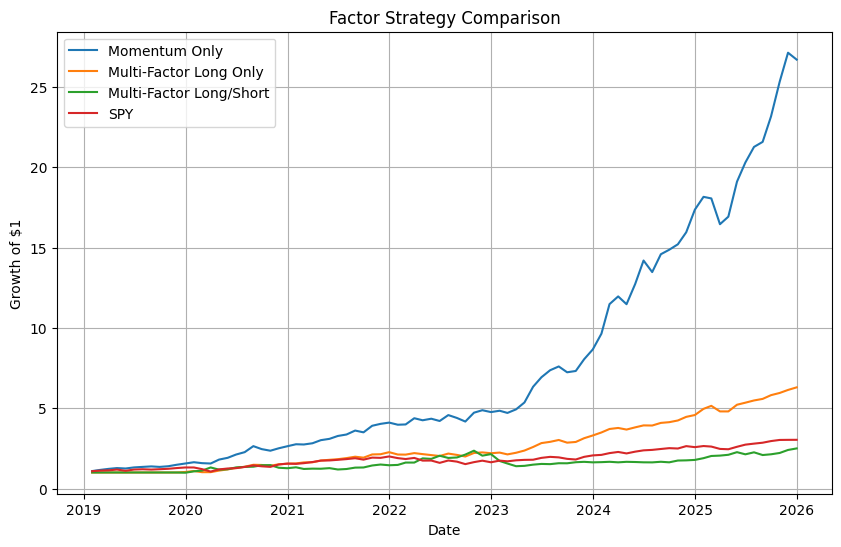

In [57]:
plt.figure(figsize=(10, 6))

plt.plot(strategy_cum, label="Momentum Only")
plt.plot(multi_cum, label="Multi-Factor Long Only")
plt.plot(long_short_cum, label="Multi-Factor Long/Short")
plt.plot(spy_cum, label="SPY")

plt.title("Factor Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.savefig("charts/factor_strategy_comparison.png")
plt.show()

In [53]:
final_performance = pd.DataFrame({
    "Momentum Only": [
        annualized_return(strategy_returns),
        annualized_volatility(strategy_returns),
        sharpe_ratio(strategy_returns),
        max_drawdown(strategy_cum)
    ],
    "Multi-Factor Long Only": [
        annualized_return(multi_strategy_returns),
        annualized_volatility(multi_strategy_returns),
        sharpe_ratio(multi_strategy_returns),
        max_drawdown(multi_cum)
    ],
    "Multi-Factor Long/Short": [
        annualized_return(long_short_returns),
        annualized_volatility(long_short_returns),
        sharpe_ratio(long_short_returns),
        max_drawdown(long_short_cum)
    ],
    "SPY": [
        annualized_return(spy_returns),
        annualized_volatility(spy_returns),
        sharpe_ratio(spy_returns),
        max_drawdown(spy_cum)
    ]
}, index=[
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
])

final_performance

,Momentum Only,Multi-Factor Long Only,Multi-Factor Long/Short,SPY
Annualized Return,0.598776,0.300726,0.139732,0.171814
Annualized Volatility,0.201177,0.143373,0.209393,0.165770
Sharpe Ratio,2.976357,2.097509,0.667319,1.036460
Max Drawdown,-0.108042,-0.119387,-0.409786,-0.239272


## Key Takeaways

- Momentum produced strong returns but may be overstated due to concentrated winners.
- Adding volatility improved stability and risk-adjusted performance.
- Long/short reduced market exposure but revealed weaker short-side signal strength.